# NetworkX demo
This notebook demonstrates basic NetworkX usage: create a graph, inspect properties, compute shortest paths, and draw the graph.

# imports

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import itertools
%matplotlib inline

# Sample code

In [ ]:
# Build a sample network (Erdos-Renyi random graph)
G = nx.erdos_renyi_graph(10, 0.4, seed=42)

# Add meaningful labels and edge weights
labels = {i: f"Node {i}" for i in G.nodes()}
for u, v in G.edges():
    G[u][v]["weight"] = round(0.1 + (u + v) * 0.05, 2)

print(f"Nodes : {G.number_of_nodes()}")
print(f"Edges : {G.number_of_edges()}")
print(f"Density: {nx.density(G):.2f}")


## Shortest path

In [ ]:
# Shortest path example (handles no-path case)
try:
    path = nx.shortest_path(G, source=0, target=5)
    print('Shortest path 0->5:', path)
except nx.NetworkXNoPath:
    print('No path between 0 and 5')

## Connected components

In [ ]:
# Connected components and centrality
print('Connected components:', list(nx.connected_components(G)))
print('Degree centrality:', nx.degree_centrality(G))

## Plot the graph

In [ ]:
# Draw the graph
plt.figure(figsize=(6,4))
nx.draw(G, with_labels=True, node_color='lightblue', node_size=500, edge_color='gray')
plt.title('Erdos-Renyi Graph (n=10, p=0.3)')
plt.show()

# Find all triangles

## cliques approach

In [ ]:
triangles = [c for c in nx.enumerate_all_cliques(G) if len(c) == 3]
print(f"Found {len(triangles)} triangles:")
print(*triangles, sep="\n")

## manual check using combinations (faster on large sparse graphs)

In [ ]:

triangles = [
    (u, v, w)
    for u, v, w in itertools.combinations(G.nodes(), 3)
    if G.has_edge(u, v) and G.has_edge(v, w) and G.has_edge(u, w)
]
print(f"Found {len(triangles)} triangles:")
print(*triangles, sep="\n")

# Display all cliques

In [ ]:
all_cliques = list(nx.enumerate_all_cliques(G=G))
print(f"Found {len(list(all_cliques))} cliques in total.")

In [ ]:
cliques_sorted = sorted(all_cliques, key=len, reverse=True)
print("Largest cliques:")
for clique in cliques_sorted:
    print(clique)

In [ ]:
lst[1]

## Render each clique

In [ ]:
all_cliques = list(nx.enumerate_all_cliques(G))  # materialise the generator
cliques_with_length_gt_3 = [c for c in all_cliques if len(c) >= 3]
pos = nx.spring_layout(G, seed=42)  # shared layout for all subplots

cols = 4
rows = -(-len(all_cliques) // cols)  # ceiling division
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
axes = axes.flatten()

for ax, clique in zip(axes, cliques_with_length_gt_3):
    subG = G.subgraph(clique)
    sub_pos = {n: pos[n] for n in clique}
    nx.draw(subG, pos=sub_pos, ax=ax, with_labels=True,
            node_color="lightcoral", node_size=600, edge_color="steelblue", width=2)
    ax.set_title(f"Clique {clique}", fontsize=8)

# hide unused axes
for ax in axes[len(cliques_with_length_gt_3):]:
    ax.set_visible(False)

plt.suptitle(f"All {len(cliques_with_length_gt_3)} cliques in the graph", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


NameError: name 'G' is not defined

# Cliques larger than 4

## Construct the graph

In [26]:
import itertools

G2 = nx.Graph()

# Clique of size 3: nodes 0-2
clique3 = [0, 1, 2]
G2.add_edges_from(itertools.combinations(clique3, 2))

# Clique of size 4: nodes 3-6
clique4 = [3, 4, 5, 6]
G2.add_edges_from(itertools.combinations(clique4, 2))

# Clique of size 5: nodes 7-11
clique5 = [7, 8, 9, 10, 11]
G2.add_edges_from(itertools.combinations(clique5, 2))

# Bridge edges to keep the graph connected
G2.add_edge(2, 3)
G2.add_edge(6, 7)

print(f"Nodes: {G2.number_of_nodes()}, Edges: {G2.number_of_edges()}")
all_cliques = list(nx.enumerate_all_cliques(G2))
max_cliques = [c for c in all_cliques if len(c) >= 3]
print(f"Cliques of size >= 3: {max_cliques}")


Nodes: 12, Edges: 21
Cliques of size >= 3: [[0, 1, 2], [3, 4, 5], [3, 4, 6], [3, 5, 6], [4, 5, 6], [7, 8, 9], [7, 8, 10], [7, 8, 11], [7, 9, 10], [7, 9, 11], [7, 10, 11], [8, 9, 10], [8, 9, 11], [8, 10, 11], [9, 10, 11], [3, 4, 5, 6], [7, 8, 9, 10], [7, 8, 9, 11], [7, 8, 10, 11], [7, 9, 10, 11], [8, 9, 10, 11], [7, 8, 9, 10, 11]]


## Render the graph

C:\Users\saurabhd\AppData\Local\Temp\ipykernel_26636\226401673.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


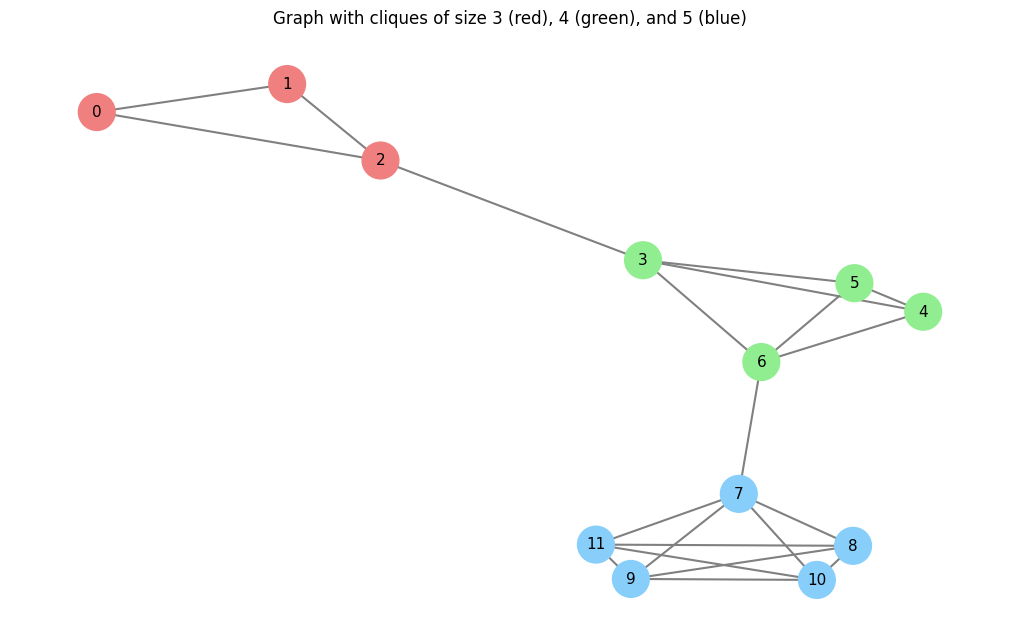

In [27]:
pos2 = nx.spring_layout(G2, seed=42)

# Colour nodes by which clique group they belong to
color_map = {}
for n in clique3:
    color_map[n] = "lightcoral"
for n in clique4:
    color_map[n] = "lightgreen"
for n in clique5:
    color_map[n] = "lightskyblue"

node_colors = [color_map.get(n, "white") for n in G2.nodes()]

plt.figure(figsize=(10, 6))
nx.draw(G2, pos=pos2, with_labels=True, node_color=node_colors,
        node_size=700, edge_color="gray", width=1.5, font_size=11)
plt.title("Graph with cliques of size 3 (red), 4 (green), and 5 (blue)")
plt.tight_layout()
plt.show()


In [ ]:
g2.add_node("A")
g2.add_node("B")
g2.add_node("C")
g2.add_node("D")
g2.add_node("E")

In [18]:
g2.add_edge("A", "D")
g2.add_edge("B", "D")  # Create a graphg2.add_edge("C", "D") 

g2.add_edge("B", "A")
g2.add_edge("A", "C")
g2.add_edge("C", "B")  
g2.add_edge("E", "A")

## Render

In [ ]:
plt.figure(figsize=(6, 4))
nx.draw(g2, with_labels=True, node_color='lightblue',
        node_size=500, edge_color='gray')
plt.title('Erdos-Renyi Graph (n=10, p=0.3)')
plt.show()

## Cliques

In [ ]:
g2=nx.Graph()


print(f"Found {len(all_cliques)} cliques in total.")

cliques_with_length_gt_3 = [c for c in all_cliques if len(c) >= 3]

In [25]:
print(f"Cliques of size >= 3: {cliques_with_length_gt_3}")

Cliques of size >= 3: [['A', 'B', 'C'], ['A', 'B', 'D'], ['A', 'C', 'D'], ['B', 'C', 'D'], ['A', 'B', 'C', 'D']]
